In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Data processing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# ML models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

# Upload and Analyze the Data
# Using merged sentiment and NVDA data to start

In [4]:
# Load data files
price_data = pd.read_csv('/content/sample_data/NVIDIA.csv')
sentiment_data = pd.read_csv('/content/sample_data/merged2_with_sentiment.csv')

# Quick look at both datasets
print("NVDA Price Data (First 5 rows):")
print(price_data.head())
print("\nPrice Data Info:")
print(price_data.info())

print("\nSentiment Data (First 5 rows):")
print(sentiment_data.head())
print("\nSentiment Data Info:")
print(sentiment_data.info())

# Filter sentiment data for NVDA only
nvda_sentiment = sentiment_data[sentiment_data['ticker'] == 'NVDA'].copy()
print(f"\nNumber of Nvidia sentiment records: {len(nvda_sentiment)}")

# Check sentiment distribution
print("\nSentiment category distribution:")
print(nvda_sentiment['sentiment_category'].value_counts())

NVDA Price Data (First 5 rows):
         Date Close/Last     Volume     Open     High      Low
0  04/29/2025    $109.02  170444300  $107.67  $110.20  $107.44
1  04/28/2025    $108.73  207708500  $109.69  $110.37  $106.02
2  04/25/2025    $111.01  251064700  $106.85  $111.92  $105.73
3  04/24/2025    $106.43  220815000  $103.48  $106.54  $103.11
4  04/23/2025    $102.71  247526000  $104.52  $104.80  $102.02

Price Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        250 non-null    object
 1   Close/Last  250 non-null    object
 2   Volume      250 non-null    int64 
 3   Open        250 non-null    object
 4   High        250 non-null    object
 5   Low         250 non-null    object
dtypes: int64(1), object(5)
memory usage: 11.8+ KB
None

Sentiment Data (First 5 rows):
            as_of_date ticker  \
0  2025-04-30 12:54:36   TS

# Data Cleaning and Preparation

In [5]:
# Clean price data
def clean_price_data(df):
    cleaned_df = df.copy()

    # Convert price columns to numeric, removing $ signs
    price_cols = ['Close/Last', 'Open', 'High', 'Low']
    for col in price_cols:
        cleaned_df[col] = cleaned_df[col].str.replace('$', '').astype(float)

    # Convert date to datetime
    cleaned_df['Date'] = pd.to_datetime(cleaned_df['Date'])

    # Sort by date
    cleaned_df = cleaned_df.sort_values('Date')

    return cleaned_df

# Clean sentiment data
def clean_sentiment_data(df):
    cleaned_df = df.copy()

    # Convert date to datetime
    cleaned_df['as_of_date'] = pd.to_datetime(cleaned_df['as_of_date'])

    # Extract just the date part (not time)
    cleaned_df['date'] = cleaned_df['as_of_date'].dt.date
    cleaned_df['date'] = pd.to_datetime(cleaned_df['date'])

    return cleaned_df

# Clean the datasets
cleaned_price = clean_price_data(price_data)
cleaned_sentiment = clean_sentiment_data(nvda_sentiment)

print("Cleaned price data sample:")
print(cleaned_price.head())
print("\nCleaned sentiment data sample:")
print(cleaned_sentiment.head())

Cleaned price data sample:
          Date  Close/Last     Volume   Open   High    Low
249 2024-04-30       86.40  363708700  87.24  88.82  86.30
248 2024-05-01       83.04  559863200  85.08  86.00  81.25
247 2024-05-02       85.82  377897500  84.45  86.24  83.20
246 2024-05-03       88.79  398340700  87.79  89.28  87.04
245 2024-05-06       92.14  376202600  89.39  92.22  89.06

Cleaned sentiment data sample:
           as_of_date ticker  \
2 2025-04-30 12:00:12   NVDA   
4 2025-04-30 10:05:00   NVDA   
5 2025-04-30 09:18:38   NVDA   
6 2025-04-30 09:08:00   NVDA   
8 2025-04-30 06:51:00   NVDA   

                                            headline  \
2  NVIDIA Sets Conference Call for First-Quarter ...   
4  ClearBridge Appreciation Portfolios Q1 2025 Co...   
5  Nvidia's Risk To Chinese Trade Restrictions Ma...   
6  3 Reasons Arista Networks Could Rally Signific...   
8  Nvidia’s stock gets a rare sell call – due to ...   

                                           news_text     

# Aggregate Sentiment by Day

In [6]:
# Aggregate sentiment by day
daily_sentiment = cleaned_sentiment.groupby('date').agg({
    'sentiment_score': 'mean',
    'bullish_probability': 'mean',
    'bearish_probability': 'mean',
    'neutral_probability': 'mean',
    'confidence': 'mean'
}).reset_index()

# Count articles by sentiment category per day
sentiment_counts = pd.crosstab(
    cleaned_sentiment['date'],
    cleaned_sentiment['sentiment_category']
).reset_index()

# Ensure all categories exist (handle days with missing categories)
for category in ['bullish', 'bearish', 'neutral']:
    if category not in sentiment_counts.columns:
        sentiment_counts[category] = 0

# Merge counts with daily sentiment
daily_sentiment = daily_sentiment.merge(sentiment_counts, on='date', how='left')

# Fill NaN values (days with no articles in a category)
daily_sentiment = daily_sentiment.fillna(0)

# Calculate additional sentiment features
daily_sentiment['net_sentiment'] = daily_sentiment['bullish'] - daily_sentiment['bearish']
daily_sentiment['bull_bear_ratio'] = daily_sentiment['bullish'] / (daily_sentiment['bearish'] + 0.001)  # Avoid division by zero
daily_sentiment['total_articles'] = daily_sentiment['bullish'] + daily_sentiment['bearish'] + daily_sentiment['neutral']

print("Daily sentiment aggregation (first 5 rows):")
print(daily_sentiment.head())

Daily sentiment aggregation (first 5 rows):
        date  sentiment_score  bullish_probability  bearish_probability  \
0 2024-10-28         0.047907             0.063867             0.015960   
1 2024-11-07        -0.023125             0.026338             0.049462   
2 2024-11-24         0.336358             0.381457             0.045098   
3 2024-11-25         0.050983             0.289249             0.238266   
4 2024-11-26         0.116199             0.292693             0.176494   

   neutral_probability  confidence  bearish  bullish  neutral  net_sentiment  \
0             0.920172    0.920172        0        0        1              0   
1             0.924200    0.924200        0        0        1              0   
2             0.573445    0.828135        2       15        7             13   
3             0.472484    0.842393       10       20       11             10   
4             0.530812    0.820038       15       22       13              7   

   bull_bear_ratio  tota

# Calculate Price Features and Returns

In [7]:
# Add technical indicators and returns to price data
def add_price_features(df):
    df = df.copy()

    # Calculate returns
    df['daily_return'] = df['Close/Last'].pct_change()
    df['next_day_return'] = df['daily_return'].shift(-1)

    # Target variable - next day price direction
    df['price_up_next_day'] = (df['next_day_return'] > 0).astype(int)

    # Add some basic technical indicators
    df['ma5'] = df['Close/Last'].rolling(window=5).mean()
    df['ma10'] = df['Close/Last'].rolling(window=10).mean()
    df['ma20'] = df['Close/Last'].rolling(window=20).mean()

    # Calculate RSI (14-day)
    delta = df['Close/Last'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / (avg_loss + 0.001)  # Avoid division by zero
    df['rsi'] = 100 - (100 / (1 + rs))

    return df

# Add price features
price_features = add_price_features(cleaned_price)

print("Price data with features (first 5 rows):")
print(price_features.head())

Price data with features (first 5 rows):
          Date  Close/Last     Volume   Open   High    Low  daily_return  \
249 2024-04-30       86.40  363708700  87.24  88.82  86.30           NaN   
248 2024-05-01       83.04  559863200  85.08  86.00  81.25     -0.038889   
247 2024-05-02       85.82  377897500  84.45  86.24  83.20      0.033478   
246 2024-05-03       88.79  398340700  87.79  89.28  87.04      0.034607   
245 2024-05-06       92.14  376202600  89.39  92.22  89.06      0.037729   

     next_day_return  price_up_next_day     ma5  ma10  ma20  rsi  
249        -0.038889                  0     NaN   NaN   NaN  NaN  
248         0.033478                  1     NaN   NaN   NaN  NaN  
247         0.034607                  1     NaN   NaN   NaN  NaN  
246         0.037729                  1     NaN   NaN   NaN  NaN  
245        -0.017256                  0  87.238   NaN   NaN  NaN  


# Merge Price and Sentiments

In [8]:
# Merge price and sentiment data
def merge_datasets(price_df, sentiment_df):
    # Ensure date formats match
    price_df['Date'] = pd.to_datetime(price_df['Date'])
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

    # Merge on date
    merged_df = pd.merge(price_df, sentiment_df, left_on='Date', right_on='date', how='left')

    # Handle missing sentiment data
    # Method 1: Forward fill (carry forward last known sentiment)
    sentiment_cols = [
        'sentiment_score', 'bullish_probability', 'bearish_probability',
        'neutral_probability', 'confidence', 'bullish', 'bearish',
        'neutral', 'net_sentiment', 'bull_bear_ratio', 'total_articles'
    ]

    merged_df[sentiment_cols] = merged_df[sentiment_cols].fillna(method='ffill')

    # For any remaining NaNs (e.g., at the beginning), fill with neutral values
    # This is a simple approach - you might want to use more sophisticated imputation
    fill_values = {
        'sentiment_score': 0,
        'bullish_probability': 0.33,
        'bearish_probability': 0.33,
        'neutral_probability': 0.34,
        'confidence': 0.5,
        'bullish': 0,
        'bearish': 0,
        'neutral': 0,
        'net_sentiment': 0,
        'bull_bear_ratio': 1,
        'total_articles': 0
    }

    merged_df = merged_df.fillna(fill_values)

    return merged_df

# Merge the datasets
merged_data = merge_datasets(price_features, daily_sentiment)

print("Merged data sample (first 5 rows):")
print(merged_data.head())
print(f"\nMerged data shape: {merged_data.shape}")

# Check for missing values after merging
print("\nMissing values after merging:")
print(merged_data.isnull().sum())

Merged data sample (first 5 rows):
        Date  Close/Last     Volume   Open   High    Low  daily_return  \
0 2024-04-30       86.40  363708700  87.24  88.82  86.30           NaN   
1 2024-05-01       83.04  559863200  85.08  86.00  81.25     -0.038889   
2 2024-05-02       85.82  377897500  84.45  86.24  83.20      0.033478   
3 2024-05-03       88.79  398340700  87.79  89.28  87.04      0.034607   
4 2024-05-06       92.14  376202600  89.39  92.22  89.06      0.037729   

   next_day_return  price_up_next_day     ma5  ma10  ma20  rsi date  \
0        -0.038889                  0     NaN   NaN   NaN  NaN  NaT   
1         0.033478                  1     NaN   NaN   NaN  NaN  NaT   
2         0.034607                  1     NaN   NaN   NaN  NaN  NaT   
3         0.037729                  1     NaN   NaN   NaN  NaN  NaT   
4        -0.017256                  0  87.238   NaN   NaN  NaN  NaT   

   sentiment_score  bullish_probability  bearish_probability  \
0              0.0           

<ipython-input-8-ac103c64e351>:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df[sentiment_cols] = merged_df[sentiment_cols].fillna(method='ffill')


# Feature Engineering

In [9]:
# Feature engineering
def engineer_features(df):
    df = df.copy()

    # Sentiment momentum (change over past days)
    df['sentiment_mom_3d'] = df['sentiment_score'].diff(3)
    df['net_sentiment_mom_3d'] = df['net_sentiment'].diff(3)

    # Sentiment moving averages
    df['sentiment_ma5'] = df['sentiment_score'].rolling(window=5).mean()

    # Volume-weighted sentiment
    df['volume_norm'] = df['Volume'] / df['Volume'].rolling(window=20).mean()
    df['volume_weighted_sentiment'] = df['sentiment_score'] * df['volume_norm']

    # Moving average crossovers
    df['ma_crossover'] = ((df['ma5'] > df['ma20']) & (df['ma5'].shift() <= df['ma20'].shift())).astype(int)

    # Sentiment and price agreement
    df['sentiment_price_agree'] = ((df['sentiment_score'] > 0) & (df['daily_return'] > 0) |
                                  (df['sentiment_score'] < 0) & (df['daily_return'] < 0)).astype(int)

    # Day of week
    df['day_of_week'] = df['Date'].dt.dayofweek

    # Drop rows with NaN (usually at the beginning due to rolling calculations)
    df = df.dropna()

    return df

# Apply feature engineering
feature_data = engineer_features(merged_data)

print("Data after feature engineering (first 5 rows):")
print(feature_data.head())
print(f"\nFeature data shape after dropping NaNs: {feature_data.shape}")

Data after feature engineering (first 5 rows):
          Date  Close/Last     Volume    Open    High     Low  daily_return  \
125 2024-10-28      140.52  173586700  143.00  143.14  140.05     -0.007206   
133 2024-11-07      148.88  207323300  146.39  148.93  146.17      0.022457   
145 2024-11-25      136.02  344941900  141.99  142.05  135.82     -0.041775   
146 2024-11-26      136.92  190287700  137.70  139.30  135.67      0.006617   
147 2024-11-27      135.34  226370900  135.01  137.22  131.80     -0.011540   

     next_day_return  price_up_next_day      ma5     ma10      ma20  \
125         0.005195                  1  141.124  139.158  133.8070   
133        -0.008396                  0  141.170  140.126  139.1825   
145         0.006617                  1  143.508  144.099  142.6540   
146        -0.011540                  0  141.490  142.962  142.4375   
147         0.021501                  1  139.380  141.869  142.2375   

           rsi       date  sentiment_score  bullish

# Train/Test Split

In [10]:
# Define features to use
feature_cols = [
    # Price-based features
    'daily_return', 'ma5', 'ma10', 'ma20', 'rsi', 'Volume',

    # Sentiment features
    'sentiment_score', 'bullish_probability', 'bearish_probability',
    'net_sentiment', 'bull_bear_ratio', 'bullish', 'bearish', 'neutral',

    # Engineered features
    'sentiment_mom_3d', 'net_sentiment_mom_3d', 'sentiment_ma5',
    'volume_weighted_sentiment', 'ma_crossover', 'sentiment_price_agree', 'day_of_week'
]

# Target
target = 'price_up_next_day'

# Do a time-based split
test_size = 0.2
split_idx = int(len(feature_data) * (1 - test_size))
train_df = feature_data.iloc[:split_idx]
test_df = feature_data.iloc[split_idx:]

print(f"Training data: {train_df.shape}, Testing data: {test_df.shape}")

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

y_train = train_df[target]
y_test = test_df[target]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Training data: (28, 33), Testing data: (7, 33)
X_train shape: (28, 21), y_train shape: (28,)
X_test shape: (7, 21), y_test shape: (7,)


# Train and Evaluate Model

Training Random Forest model...
Training XGBoost model...

Random Forest Results:
Accuracy: 0.4286
ROC-AUC: 0.5000
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.40      0.67      0.50         3

    accuracy                           0.43         7
   macro avg       0.45      0.46      0.42         7
weighted avg       0.46      0.43      0.40         7


XGBoost Results:
Accuracy: 0.5714
ROC-AUC: 0.6667
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.50      0.67      0.57         3

    accuracy                           0.57         7
   macro avg       0.58      0.58      0.57         7
weighted avg       0.60      0.57      0.57         7



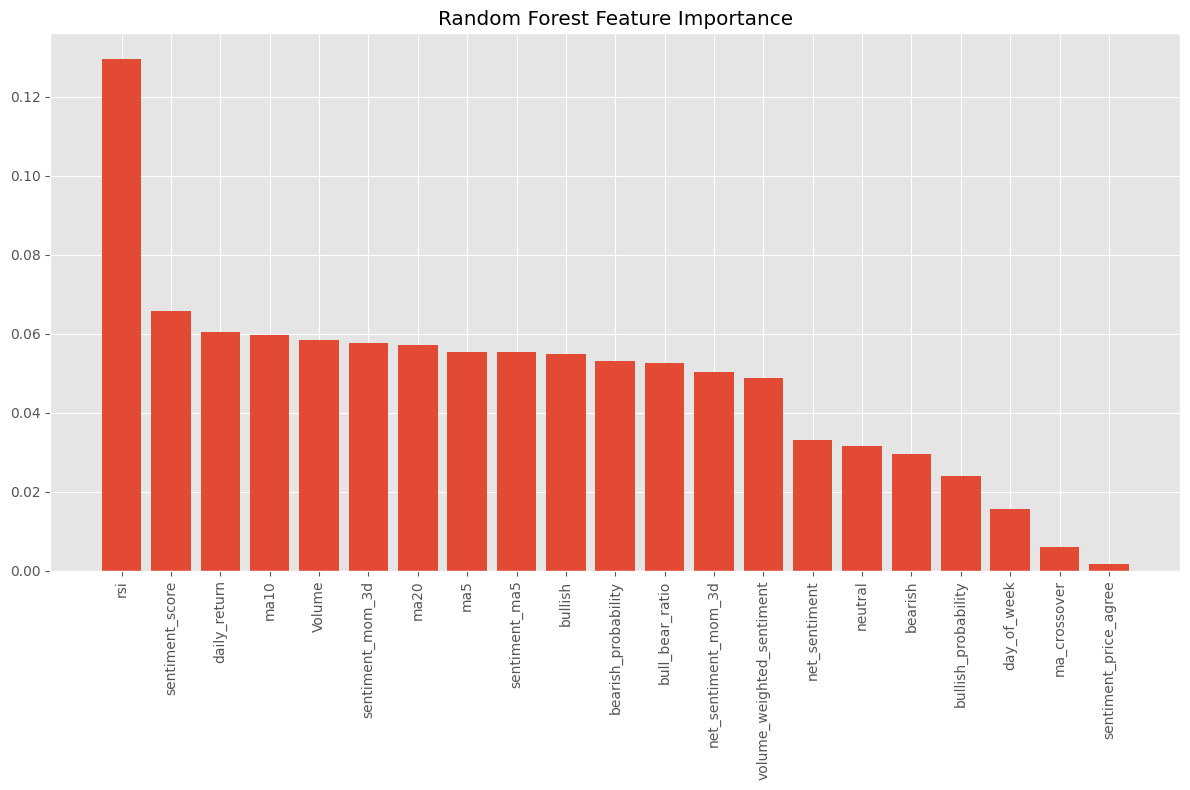

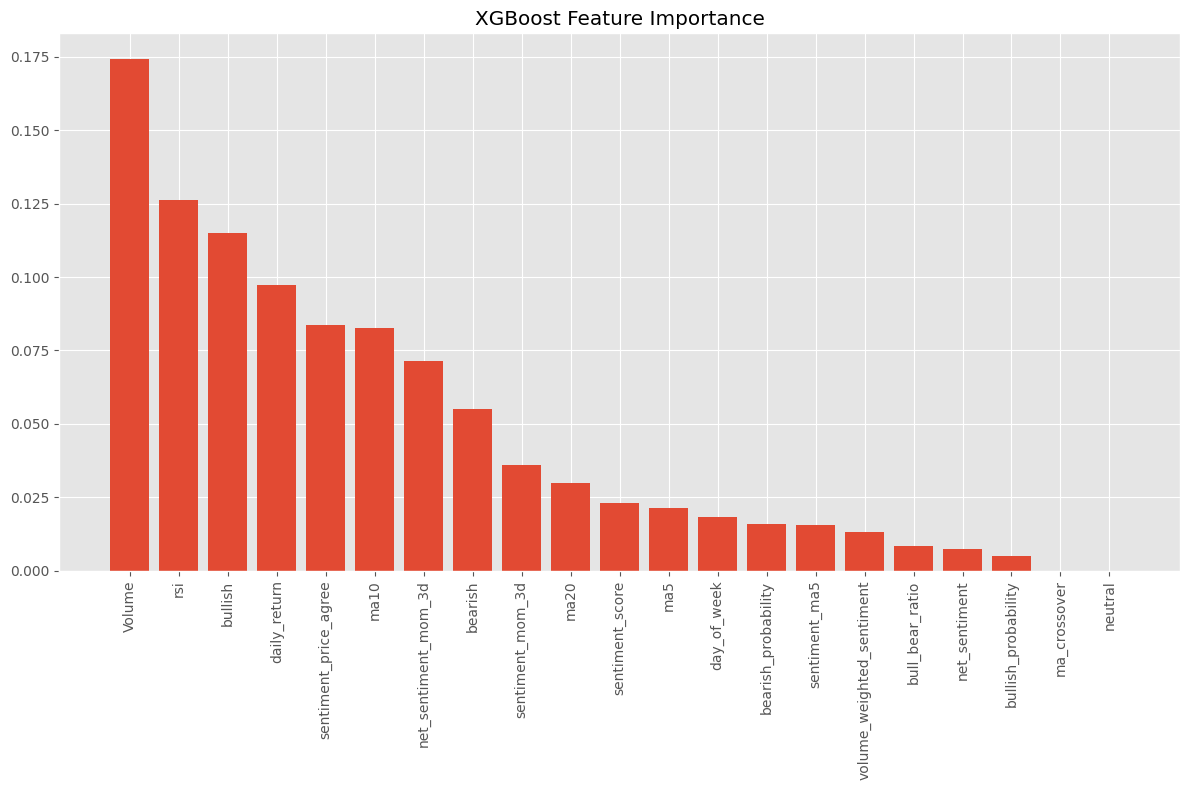

In [11]:
# Train Random Forest model
print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Train XGBoost model
print("Training XGBoost model...")
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Calculate probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate models
print("\nRandom Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")
print(classification_report(y_test, rf_pred))

print("\nXGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")
print(classification_report(y_test, xgb_pred))

# Feature importance for Random Forest
plt.figure(figsize=(12, 8))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.title('Random Forest Feature Importance')
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# Feature importance for XGBoost
plt.figure(figsize=(12, 8))
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.title('XGBoost Feature Importance')
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# Generate Trading Signals

In [12]:
# Generate trading signals based on model predictions
def generate_signals(model, X, threshold=0.55):
    # Get probabilities from the model
    probabilities = model.predict_proba(X)[:, 1]

    # Generate signals based on probability and threshold
    signals = []
    for prob in probabilities:
        if prob >= threshold:
            signals.append('BUY')
        elif prob <= (1 - threshold):
            signals.append('SELL')
        else:
            signals.append('HOLD')

    return signals, probabilities

# Generate signals
# We'll use XGBoost for this example, but you can swap for Random Forest if it performs better
xgb_signals, xgb_probs = generate_signals(xgb_model, X_test)

# Add signals to test data
test_df = test_df.copy()
test_df['signal'] = xgb_signals
test_df['probability'] = xgb_probs

print("Test data with signals (first 5 rows):")
print(test_df[['Date', 'Close/Last', 'sentiment_score', 'net_sentiment', 'signal', 'probability']].head())

# Count signal types
print("\nSignal distribution:")
print(pd.Series(xgb_signals).value_counts())

Test data with signals (first 5 rows):
          Date  Close/Last  sentiment_score  net_sentiment signal  probability
208 2025-02-28      124.92        -0.099678            0.0   SELL     0.065711
227 2025-03-27      111.43        -0.172689           -2.0    BUY     0.908797
228 2025-03-28      109.67        -0.236751          -14.0    BUY     0.908797
229 2025-03-31      108.38        -0.107133            0.0    BUY     0.969751
246 2025-04-24      106.43         0.236333           15.0   SELL     0.069862

Signal distribution:
BUY     4
SELL    3
Name: count, dtype: int64


# Backtest

In [13]:
# Simple backtesting function
def backtest_strategy(signal_df, initial_cash=10000):
    """Simple backtesting of the trading strategy"""

    # Create a copy to avoid modifying the original
    df = signal_df.copy()

    # Initialize portfolio
    portfolio = pd.DataFrame(index=df.index)
    portfolio['date'] = df['Date']
    portfolio['signal'] = df['signal']
    portfolio['price'] = df['Close/Last']
    portfolio['cash'] = initial_cash
    portfolio['shares'] = 0
    portfolio['equity'] = initial_cash

    # Execute trades based on signals
    for i in range(1, len(portfolio)):
        # Start with previous day's portfolio
        portfolio.loc[portfolio.index[i], 'cash'] = portfolio.loc[portfolio.index[i-1], 'cash']
        portfolio.loc[portfolio.index[i], 'shares'] = portfolio.loc[portfolio.index[i-1], 'shares']

        # Execute yesterday's signal at today's open price
        price = df.loc[df.index[i], 'Open']

        if portfolio.loc[portfolio.index[i-1], 'signal'] == 'BUY' and portfolio.loc[portfolio.index[i], 'cash'] > 0:
            # Calculate shares to buy (all available cash)
            shares_to_buy = portfolio.loc[portfolio.index[i], 'cash'] // price
            portfolio.loc[portfolio.index[i], 'shares'] += shares_to_buy
            portfolio.loc[portfolio.index[i], 'cash'] -= shares_to_buy * price

        elif portfolio.loc[portfolio.index[i-1], 'signal'] == 'SELL' and portfolio.loc[portfolio.index[i], 'shares'] > 0:
            # Sell all shares
            portfolio.loc[portfolio.index[i], 'cash'] += portfolio.loc[portfolio.index[i], 'shares'] * price
            portfolio.loc[portfolio.index[i], 'shares'] = 0

        # Calculate equity
        portfolio.loc[portfolio.index[i], 'equity'] = portfolio.loc[portfolio.index[i], 'cash'] + \
                                                    portfolio.loc[portfolio.index[i], 'shares'] * portfolio.loc[portfolio.index[i], 'price']

    # Calculate returns and performance metrics
    portfolio['daily_return'] = portfolio['equity'].pct_change()
    portfolio['cumulative_return'] = (1 + portfolio['daily_return']).cumprod() - 1

    # Calculate benchmark (buy and hold)
    benchmark = pd.DataFrame(index=portfolio.index)
    benchmark['date'] = portfolio['date']
    benchmark['price'] = df['Close/Last']
    shares_bought = initial_cash // df.loc[df.index[0], 'Open']
    cash_leftover = initial_cash - shares_bought * df.loc[df.index[0], 'Open']
    benchmark['equity'] = shares_bought * benchmark['price'] + cash_leftover
    benchmark['daily_return'] = benchmark['equity'].pct_change()
    benchmark['cumulative_return'] = (1 + benchmark['daily_return']).cumprod() - 1

    # Performance metrics
    total_return = portfolio['equity'].iloc[-1] / initial_cash - 1
    benchmark_return = benchmark['equity'].iloc[-1] / initial_cash - 1

    print(f"Strategy Total Return: {total_return:.2%}")
    print(f"Buy & Hold Return: {benchmark_return:.2%}")

    # Annualized Sharpe Ratio (assuming 252 trading days)
    sharpe_ratio = portfolio['daily_return'].mean() / portfolio['daily_return'].std() * np.sqrt(252)
    print(f"Strategy Sharpe Ratio: {sharpe_ratio:.2f}")

    # Maximum Drawdown
    portfolio['peak'] = portfolio['equity'].cummax()
    portfolio['drawdown'] = (portfolio['equity'] / portfolio['peak'] - 1)
    max_drawdown = portfolio['drawdown'].min()
    print(f"Maximum Drawdown: {max_drawdown:.2%}")

    return portfolio, benchmark

# Run backtest
portfolio, benchmark = backtest_strategy(test_df)

Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%


<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'cash'] -= shares_to_buy * price
<ipython-input-13-fd72bafe4243>:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9838.020000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'equity'] = portfolio.loc[portfolio.index[i], 'cash'] + \


# Visualize

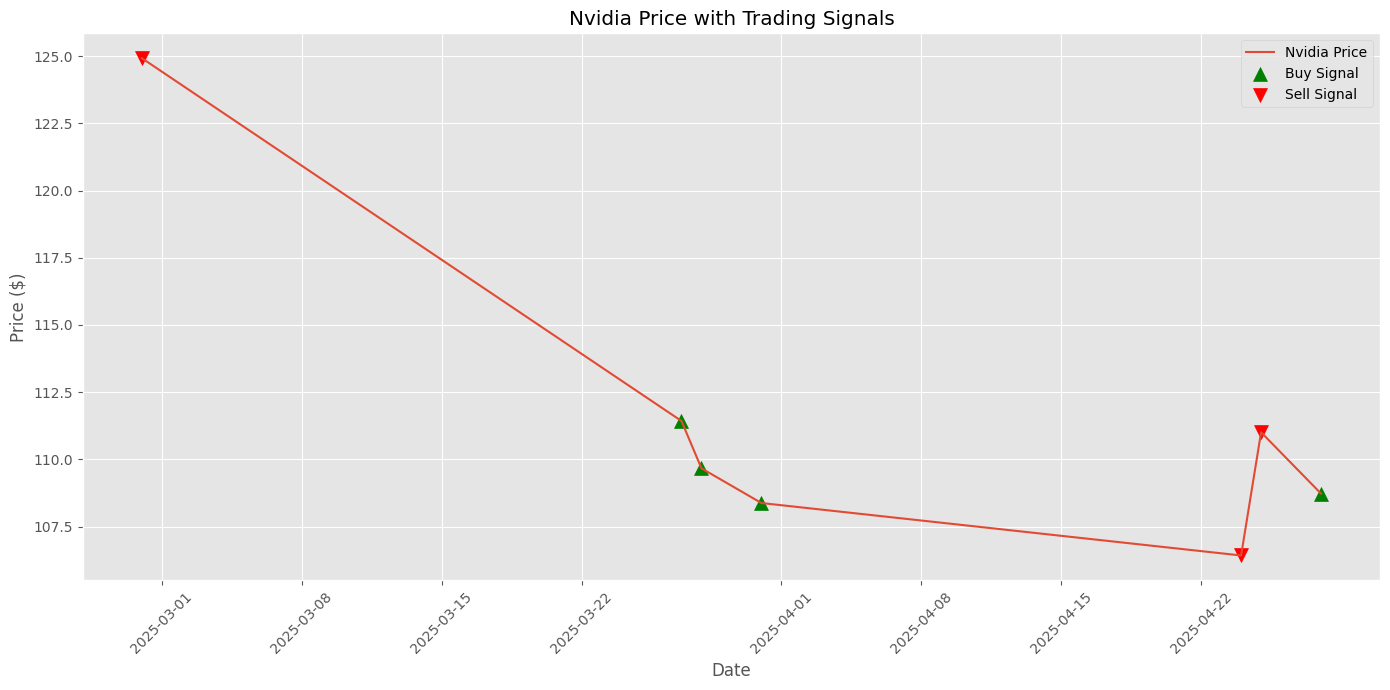

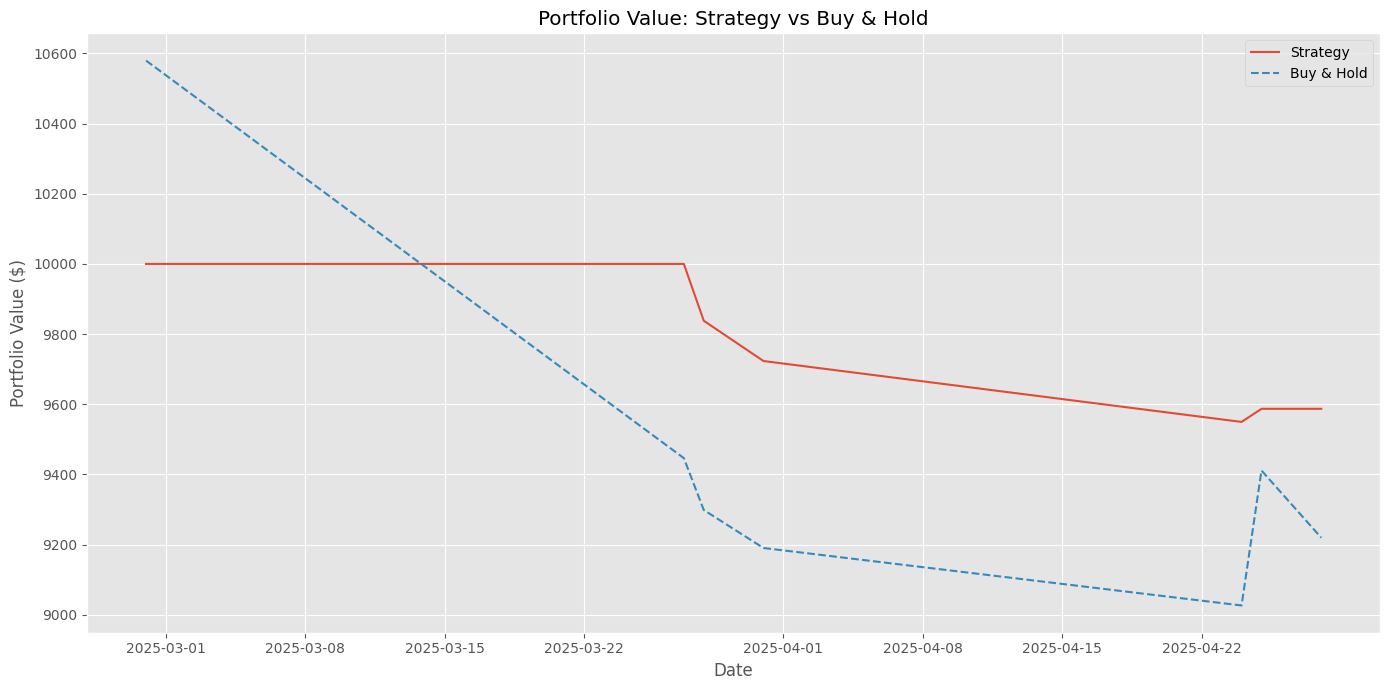

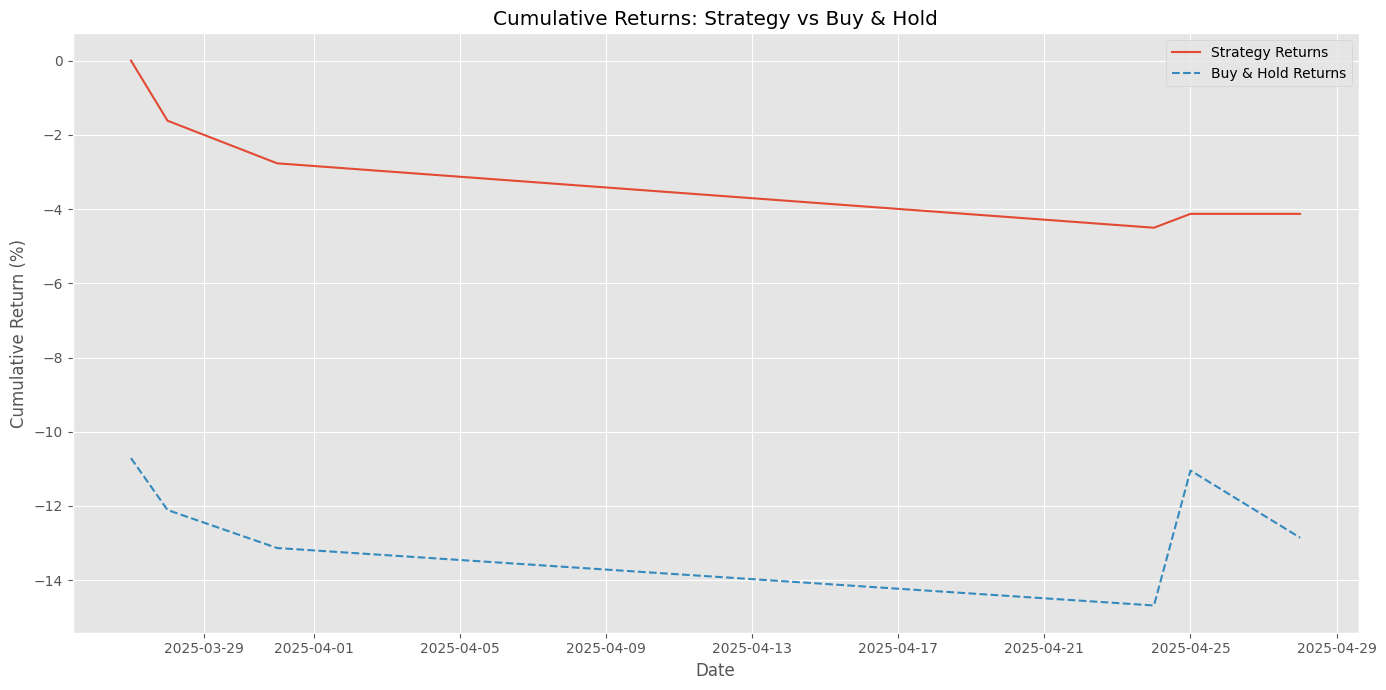

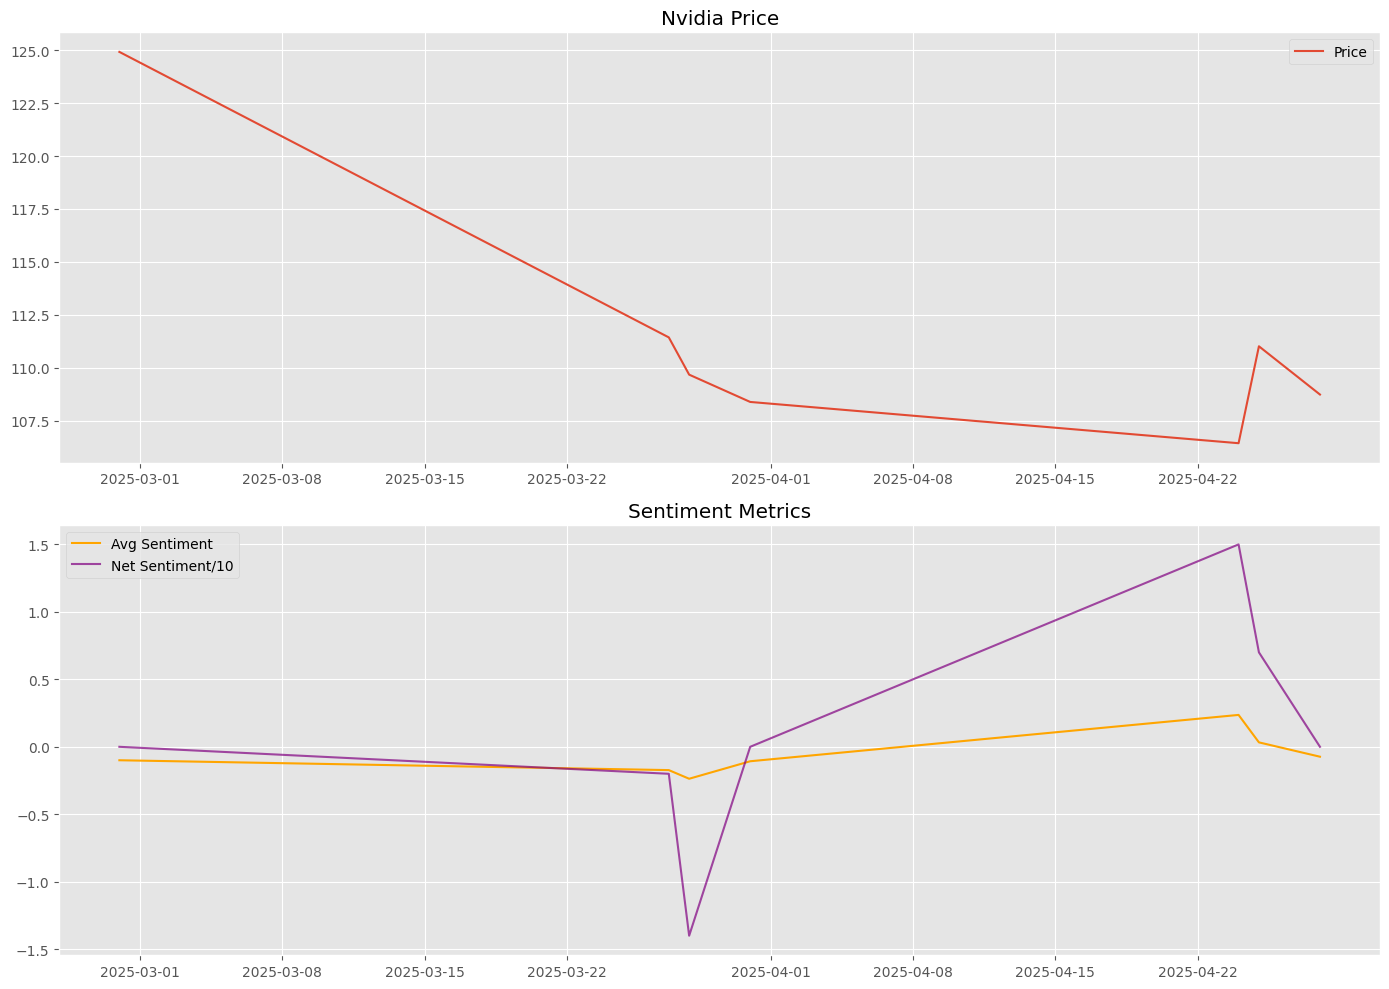

In [14]:
# Plot price and signals
plt.figure(figsize=(14, 7))
plt.plot(test_df['Date'], test_df['Close/Last'], label='Nvidia Price')

# Plot buy signals
buys = test_df[test_df['signal'] == 'BUY']
if len(buys) > 0:
    plt.scatter(buys['Date'], buys['Close/Last'], marker='^', color='green', s=100, label='Buy Signal')

# Plot sell signals
sells = test_df[test_df['signal'] == 'SELL']
if len(sells) > 0:
    plt.scatter(sells['Date'], sells['Close/Last'], marker='v', color='red', s=100, label='Sell Signal')

plt.title('Nvidia Price with Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot portfolio performance
plt.figure(figsize=(14, 7))
plt.plot(portfolio['date'], portfolio['equity'], label='Strategy')
plt.plot(benchmark['date'], benchmark['equity'], label='Buy & Hold', linestyle='--')
plt.title('Portfolio Value: Strategy vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot returns
plt.figure(figsize=(14, 7))
plt.plot(portfolio['date'], portfolio['cumulative_return'] * 100, label='Strategy Returns')
plt.plot(benchmark['date'], benchmark['cumulative_return'] * 100, label='Buy & Hold Returns', linestyle='--')
plt.title('Cumulative Returns: Strategy vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot sentiment vs price
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(test_df['Date'], test_df['Close/Last'], label='Price')
plt.title('Nvidia Price')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(test_df['Date'], test_df['sentiment_score'], label='Avg Sentiment', color='orange')
plt.plot(test_df['Date'], test_df['net_sentiment'] / 10, label='Net Sentiment/10', color='purple', alpha=0.7)
plt.title('Sentiment Metrics')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Monte Carlo Simulation With Lagged Sentiment Rates

In [15]:
# Monte Carlo simulation with lagged sentiment
def run_monte_carlo(feature_data, feature_cols, target, n_simulations=100, lag_range=(1, 5)):
    """
    Run Monte Carlo simulations with different sentiment lags
    to test trading strategy robustness
    """
    results = []

    for sim in range(n_simulations):
        # Randomly select a lag value
        lag = np.random.randint(lag_range[0], lag_range[1] + 1)

        # Create a copy of the data
        sim_data = feature_data.copy()

        # Apply lag to sentiment features
        sentiment_features = ['sentiment_score', 'net_sentiment', 'bullish', 'bearish',
                            'neutral', 'bull_bear_ratio', 'sentiment_mom_3d']

        for feature in sentiment_features:
            if feature in sim_data.columns:
                sim_data[f'{feature}_lag{lag}'] = sim_data[feature].shift(lag)

        # Drop rows with NaN from lagging
        sim_data = sim_data.dropna()

        # Update feature columns to use lagged features
        sim_feature_cols = feature_cols.copy()
        for feature in sentiment_features:
            if feature in sim_feature_cols:
                sim_feature_cols.remove(feature)
                if f'{feature}_lag{lag}' in sim_data.columns:
                    sim_feature_cols.append(f'{feature}_lag{lag}')

        # Split data
        test_size = 0.2
        split_idx = int(len(sim_data) * (1 - test_size))
        train_df = sim_data.iloc[:split_idx]
        test_df = sim_data.iloc[split_idx:]

        # Scale features
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_df[sim_feature_cols])
        X_test = scaler.transform(test_df[sim_feature_cols])

        y_train = train_df[target]
        y_test = test_df[target]

        # Train model
        model = XGBClassifier(n_estimators=100, random_state=sim)
        model.fit(X_train, y_train)

        # Generate signals
        signals, probs = generate_signals(model, X_test)

        # Add signals to test data
        test_df = test_df.copy()
        test_df['signal'] = signals
        test_df['probability'] = probs

        # Run backtest
        portfolio, benchmark = backtest_strategy(test_df, initial_cash=10000)

        # Store results
        results.append({
            'simulation': sim + 1,
            'lag': lag,
            'portfolio': portfolio,
            'benchmark': benchmark,
            'final_equity': portfolio['equity'].iloc[-1],
            'total_return': portfolio['equity'].iloc[-1] / 10000 - 1,
            'benchmark_return': benchmark['equity'].iloc[-1] / 10000 - 1,
            'max_drawdown': portfolio['drawdown'].min(),
            'sharpe_ratio': portfolio['daily_return'].mean() / portfolio['daily_return'].std() * np.sqrt(252) if portfolio['daily_return'].std() > 0 else 0
        })

        print(f"Simulation {sim + 1}/{n_simulations} - Lag: {lag}, Return: {results[-1]['total_return']:.2%}")

    return results

# Run Monte Carlo with 20 simulations (adjust based on your computation resources)
print("Running Monte Carlo simulations with varying sentiment lags...")
mc_results = run_monte_carlo(feature_data, feature_cols, target, n_simulations=20, lag_range=(1, 5))

Running Monte Carlo simulations with varying sentiment lags...
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 1/20 - Lag: 4, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 2/20 - Lag: 1, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -2.33%
Strategy Sharpe Ratio: -13.56
Maximum Drawdown: -4.50%
Simulation 3/20 - Lag: 5, Return: -4.13%


<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'cash'] -= shares_to_buy * price
<ipython-input-13-fd72bafe4243>:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9838.020000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'equity'] = portfolio.loc[portfolio.index[i], 'cash'] + \
<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfoli

Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 4/20 - Lag: 3, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 5/20 - Lag: 1, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 6/20 - Lag: 2, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 7/20 - Lag: 1, Return: -4.13%


<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'cash'] -= shares_to_buy * price
<ipython-input-13-fd72bafe4243>:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9838.020000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'equity'] = portfolio.loc[portfolio.index[i], 'cash'] + \
<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfoli

Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 8/20 - Lag: 2, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 9/20 - Lag: 1, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 10/20 - Lag: 3, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 11/20 - Lag: 2, Return: -4.13%


<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'cash'] -= shares_to_buy * price
<ipython-input-13-fd72bafe4243>:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9838.020000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'equity'] = portfolio.loc[portfolio.index[i], 'cash'] + \
<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfoli

Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 12/20 - Lag: 4, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 13/20 - Lag: 2, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 14/20 - Lag: 1, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -2.33%
Strategy Sharpe Ratio: -13.56
Maximum Drawdown: -4.50%
Simulation 15/20 - Lag: 5, Return: -4.13%


<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'cash'] -= shares_to_buy * price
<ipython-input-13-fd72bafe4243>:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9838.020000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'equity'] = portfolio.loc[portfolio.index[i], 'cash'] + \
<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfoli

Strategy Total Return: -4.13%
Buy & Hold Return: -2.33%
Strategy Sharpe Ratio: -13.56
Maximum Drawdown: -4.50%
Simulation 16/20 - Lag: 5, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -2.33%
Strategy Sharpe Ratio: -13.56
Maximum Drawdown: -4.50%
Simulation 17/20 - Lag: 5, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 18/20 - Lag: 1, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 19/20 - Lag: 3, Return: -4.13%
Strategy Total Return: -4.13%
Buy & Hold Return: -7.80%
Strategy Sharpe Ratio: -11.77
Maximum Drawdown: -4.50%
Simulation 20/20 - Lag: 3, Return: -4.13%


<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'cash'] -= shares_to_buy * price
<ipython-input-13-fd72bafe4243>:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9838.020000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfolio.index[i], 'equity'] = portfolio.loc[portfolio.index[i], 'cash'] + \
<ipython-input-13-fd72bafe4243>:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77.39000000000124' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[portfoli

# Analyze Monte Carlo Results


Monte Carlo Simulation Summary:
       Simulation        Lag     Return  Benchmark  Outperformance  \
count    20.00000  20.000000  20.000000  20.000000       20.000000   
mean     10.50000   2.700000  -0.041296  -0.067092        0.025796   
std       5.91608   1.525226   0.000000   0.022456        0.022456   
min       1.00000   1.000000  -0.041296  -0.078036       -0.017978   
25%       5.75000   1.000000  -0.041296  -0.078036        0.036740   
50%      10.50000   2.500000  -0.041296  -0.078036        0.036740   
75%      15.25000   4.000000  -0.041296  -0.078036        0.036740   
max      20.00000   5.000000  -0.041296  -0.023318        0.036740   

       Max Drawdown     Sharpe  
count     20.000000  20.000000  
mean      -0.045034 -12.131574  
std        0.000000   0.734656  
min       -0.045034 -13.563683  
25%       -0.045034 -11.773547  
50%       -0.045034 -11.773547  
75%       -0.045034 -11.773547  
max       -0.045034 -11.773547  

Best performing simulation:
Simulation

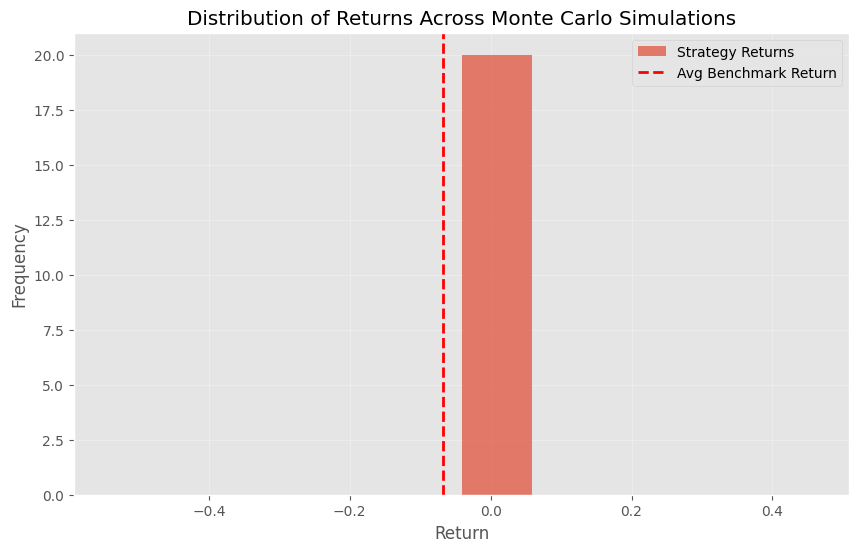

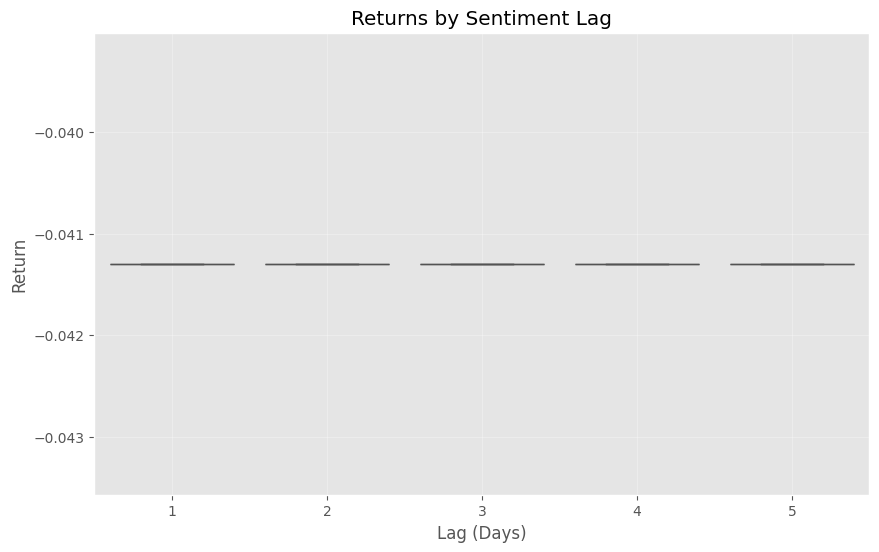

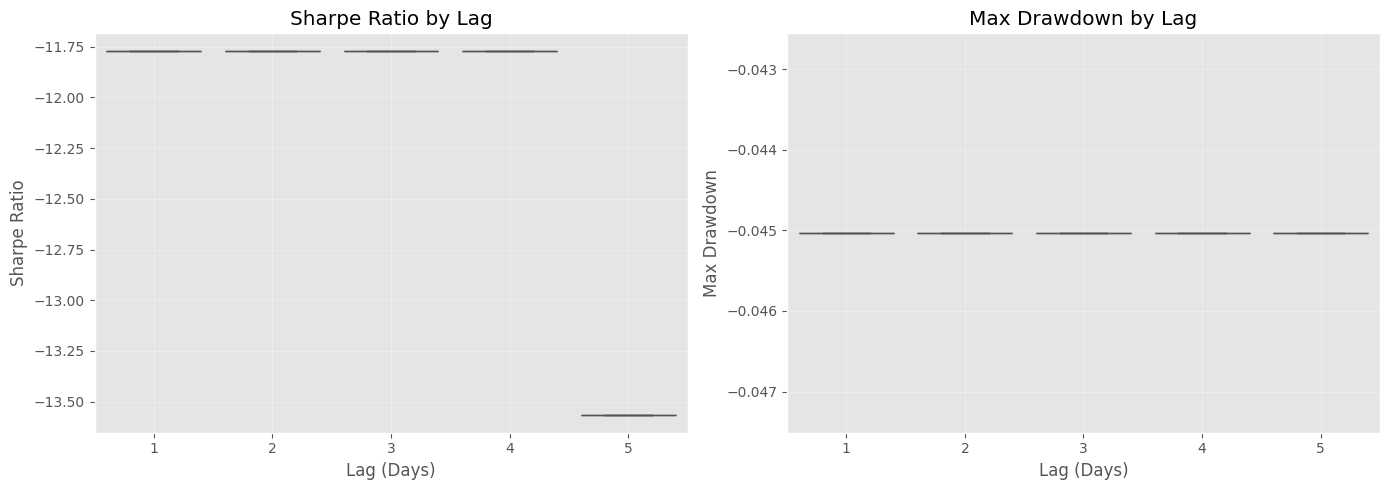

In [16]:
# Convert results to DataFrame for analysis
mc_df = pd.DataFrame([
    {
        'Simulation': r['simulation'],
        'Lag': r['lag'],
        'Return': r['total_return'],
        'Benchmark': r['benchmark_return'],
        'Outperformance': r['total_return'] - r['benchmark_return'],
        'Max Drawdown': r['max_drawdown'],
        'Sharpe': r['sharpe_ratio']
    } for r in mc_results
])

# Summary statistics
print("\nMonte Carlo Simulation Summary:")
print(mc_df.describe())

# Best performing simulation
best_sim = mc_df.loc[mc_df['Return'].idxmax()]
print("\nBest performing simulation:")
print(best_sim)

# Count how many simulations beat the benchmark
beat_benchmark = len(mc_df[mc_df['Outperformance'] > 0])
print(f"\nSimulations that beat benchmark: {beat_benchmark}/{len(mc_df)} ({beat_benchmark/len(mc_df):.1%})")

# Visualize return distribution
plt.figure(figsize=(10, 6))
plt.hist(mc_df['Return'], bins=10, alpha=0.7, label='Strategy Returns')
plt.axvline(mc_df['Benchmark'].mean(), color='red', linestyle='dashed', linewidth=2, label='Avg Benchmark Return')
plt.title('Distribution of Returns Across Monte Carlo Simulations')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot returns by lag
plt.figure(figsize=(10, 6))
sns.boxplot(x='Lag', y='Return', data=mc_df)
plt.title('Returns by Sentiment Lag')
plt.xlabel('Lag (Days)')
plt.ylabel('Return')
plt.grid(True, alpha=0.3)
plt.show()

# Plot performance metrics by lag
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Lag', y='Sharpe', data=mc_df)
plt.title('Sharpe Ratio by Lag')
plt.xlabel('Lag (Days)')
plt.ylabel('Sharpe Ratio')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(x='Lag', y='Max Drawdown', data=mc_df)
plt.title('Max Drawdown by Lag')
plt.xlabel('Lag (Days)')
plt.ylabel('Max Drawdown')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize the Best Simulation

Visualizing results for best simulation (#1) with lag 4


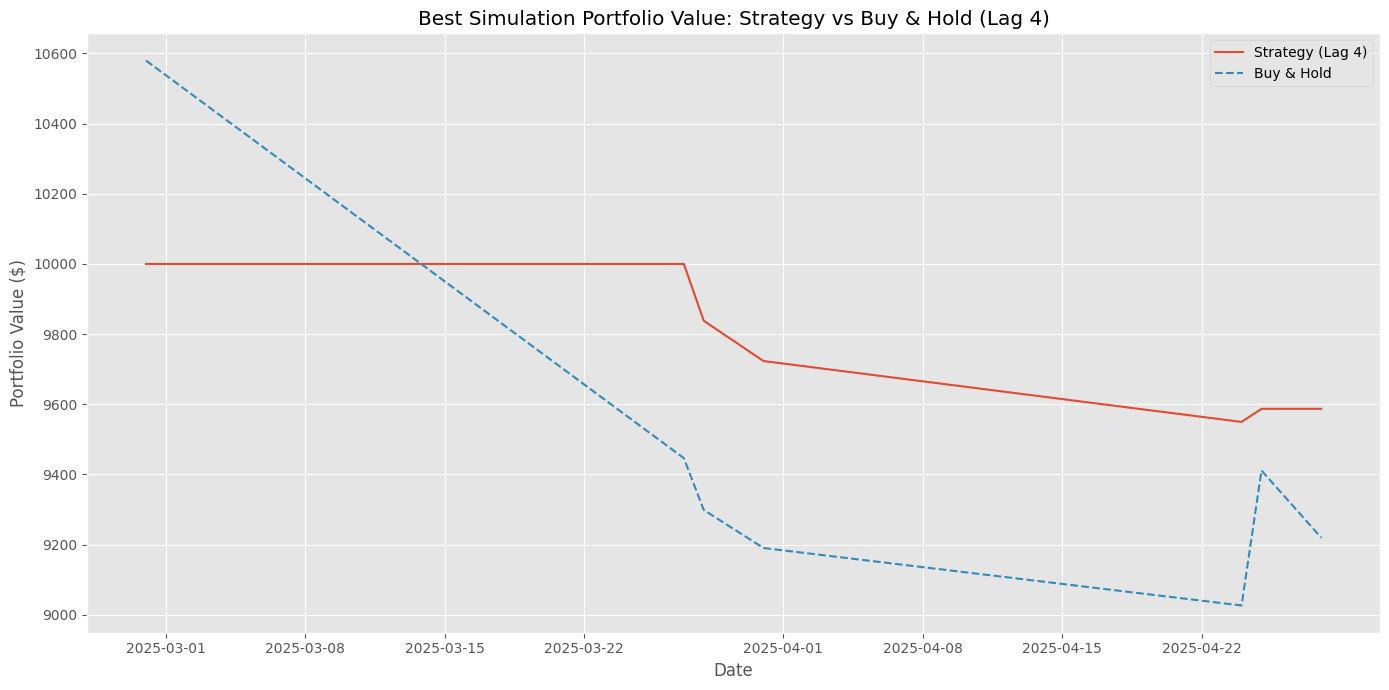

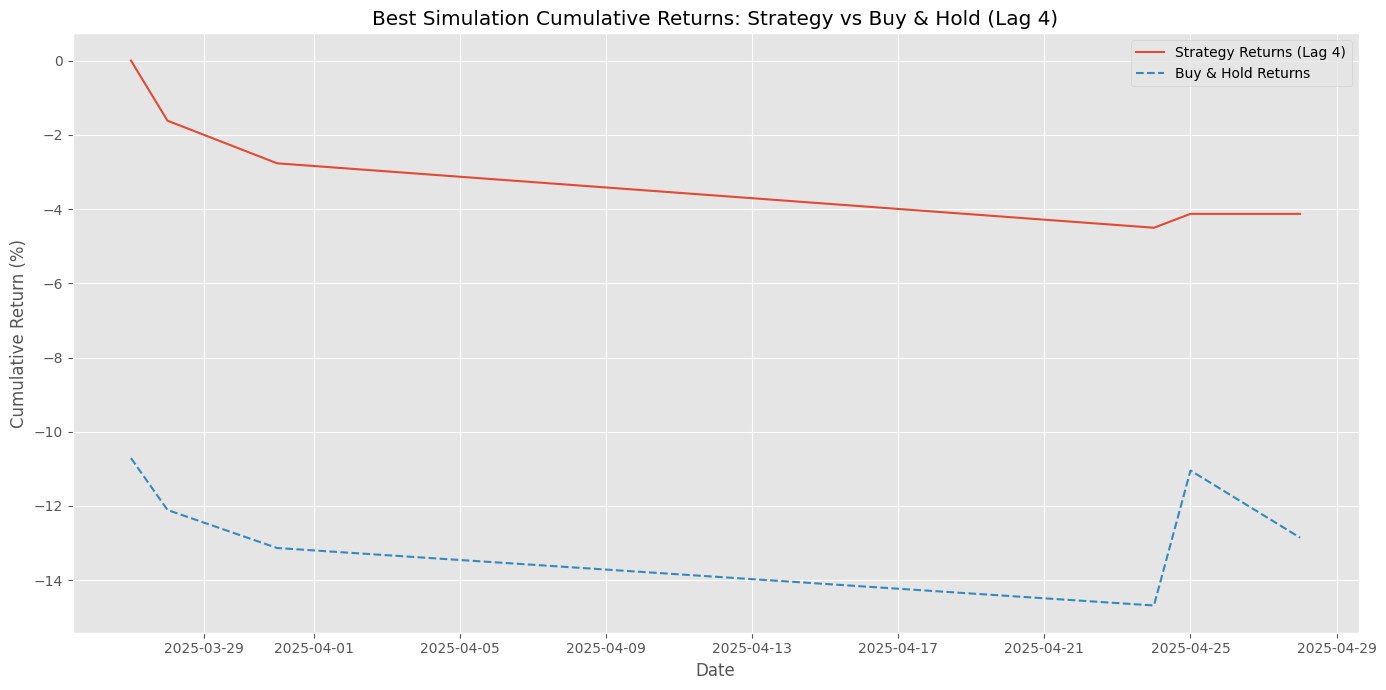

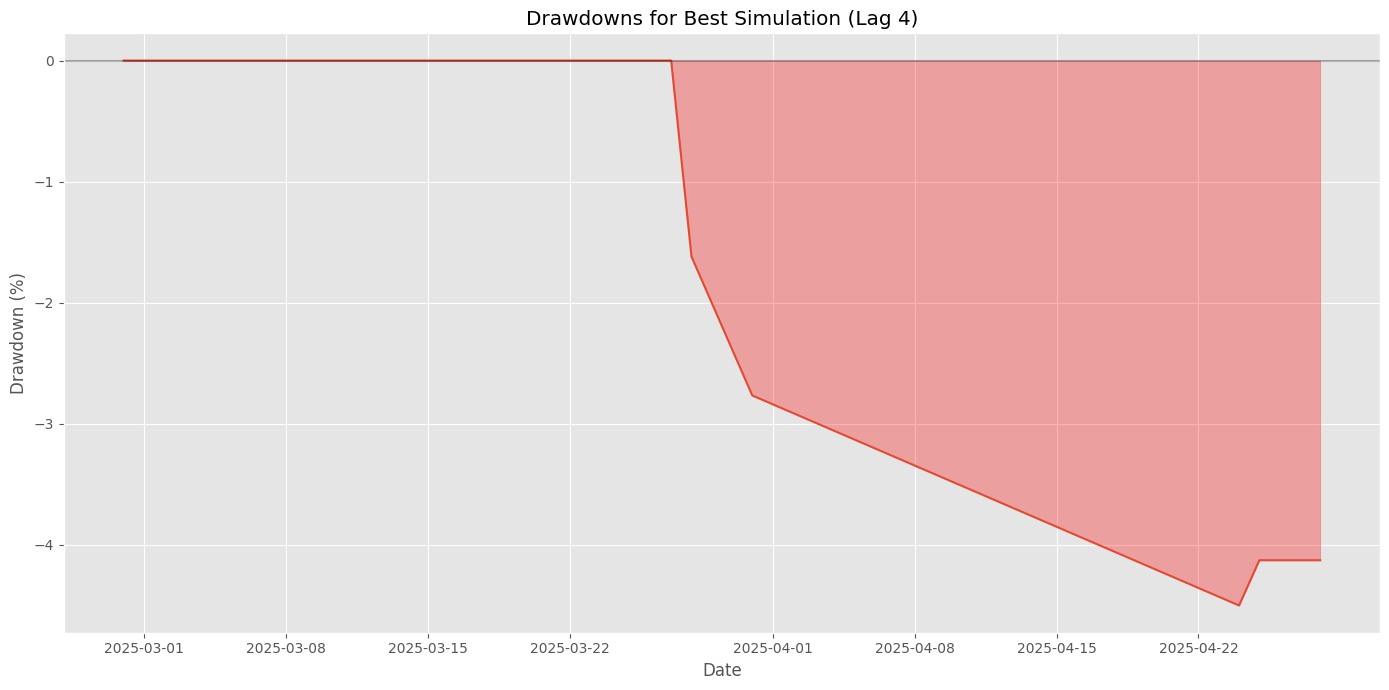

In [17]:
# Get the best simulation
best_sim_idx = mc_df['Return'].idxmax()
best_sim_num = mc_df.loc[best_sim_idx, 'Simulation']
best_lag = mc_df.loc[best_sim_idx, 'Lag']

# Find the corresponding portfolio and benchmark
best_portfolio = mc_results[int(best_sim_num) - 1]['portfolio']
best_benchmark = mc_results[int(best_sim_num) - 1]['benchmark']

print(f"Visualizing results for best simulation (#{best_sim_num}) with lag {best_lag}")

# Plot portfolio performance for best simulation
plt.figure(figsize=(14, 7))
plt.plot(best_portfolio['date'], best_portfolio['equity'], label=f'Strategy (Lag {best_lag})')
plt.plot(best_benchmark['date'], best_benchmark['equity'], label='Buy & Hold', linestyle='--')
plt.title(f'Best Simulation Portfolio Value: Strategy vs Buy & Hold (Lag {best_lag})')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot returns for best simulation
plt.figure(figsize=(14, 7))
plt.plot(best_portfolio['date'], best_portfolio['cumulative_return'] * 100, label=f'Strategy Returns (Lag {best_lag})')
plt.plot(best_benchmark['date'], best_benchmark['cumulative_return'] * 100, label='Buy & Hold Returns', linestyle='--')
plt.title(f'Best Simulation Cumulative Returns: Strategy vs Buy & Hold (Lag {best_lag})')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot drawdowns
plt.figure(figsize=(14, 7))
plt.plot(best_portfolio['date'], best_portfolio['drawdown'] * 100)
plt.title(f'Drawdowns for Best Simulation (Lag {best_lag})')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.fill_between(best_portfolio['date'], best_portfolio['drawdown'] * 100, 0, color='red', alpha=0.3)
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare across Lags

Performance comparison by lag:
   Lag  Avg Return  Avg Sharpe  Avg Max Drawdown  Beat Benchmark %
0    1   -0.041296  -11.773547         -0.045034             100.0
1    2   -0.041296  -11.773547         -0.045034             100.0
2    3   -0.041296  -11.773547         -0.045034             100.0
3    4   -0.041296  -11.773547         -0.045034             100.0
4    5   -0.041296  -13.563683         -0.045034               0.0


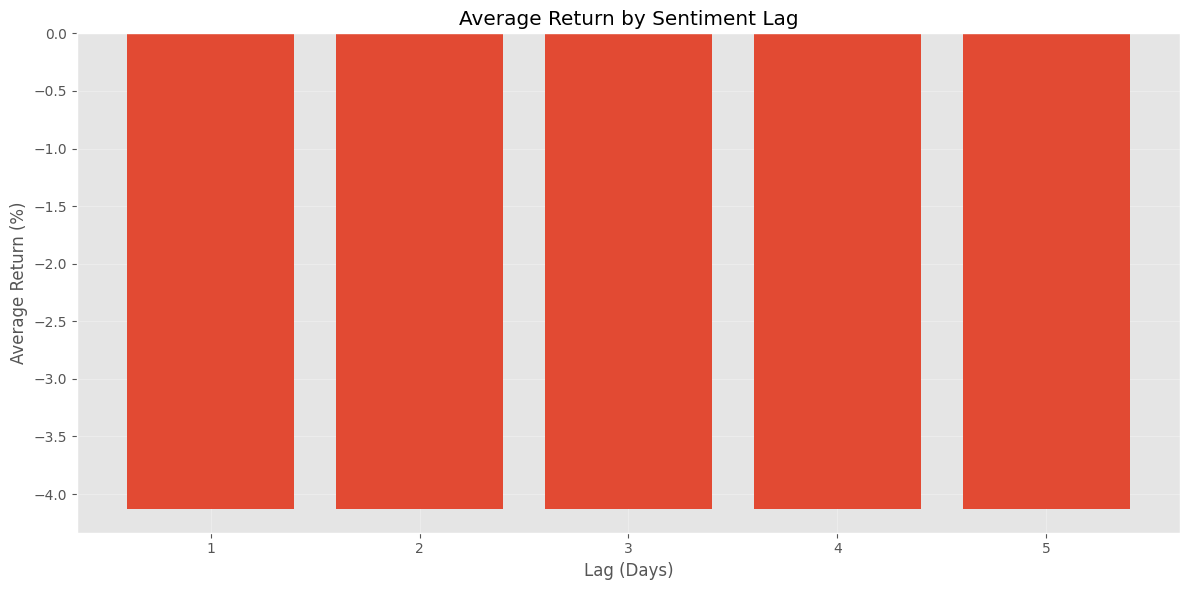

In [18]:
# Compare performance across different lags
lag_comparison = pd.DataFrame()
lag_comparison_data = []

for lag in range(1, 6):
    # Filter simulations with this lag
    lag_sims = [r for r in mc_results if r['lag'] == lag]

    if lag_sims:
        # Calculate average performance metrics
        avg_return = np.mean([s['total_return'] for s in lag_sims])
        avg_sharpe = np.mean([s['sharpe_ratio'] for s in lag_sims])
        avg_drawdown = np.mean([s['max_drawdown'] for s in lag_sims])
        beat_bm_pct = np.mean([1 if s['total_return'] > s['benchmark_return'] else 0 for s in lag_sims])

        lag_comparison_data.append({
            'Lag': lag,
            'Avg Return': avg_return,
            'Avg Sharpe': avg_sharpe,
            'Avg Max Drawdown': avg_drawdown,
            'Beat Benchmark %': beat_bm_pct * 100
        })

# Create DataFrame from the collected data
lag_comparison = pd.DataFrame(lag_comparison_data)

print("Performance comparison by lag:")
print(lag_comparison)

# Plot average return by lag
plt.figure(figsize=(12, 6))
plt.bar(lag_comparison['Lag'], lag_comparison['Avg Return'] * 100)
plt.title('Average Return by Sentiment Lag')
plt.xlabel('Lag (Days)')
plt.ylabel('Average Return (%)')
plt.xticks(lag_comparison['Lag'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze Trading Signals by Lag

Signal distribution by lag:
   Lag      Buy %     Sell %  Hold %
0    1  57.142857  42.857143     0.0
1    2  57.142857  42.857143     0.0
2    3  57.142857  42.857143     0.0
3    4  57.142857  42.857143     0.0
4    5  66.666667  33.333333     0.0


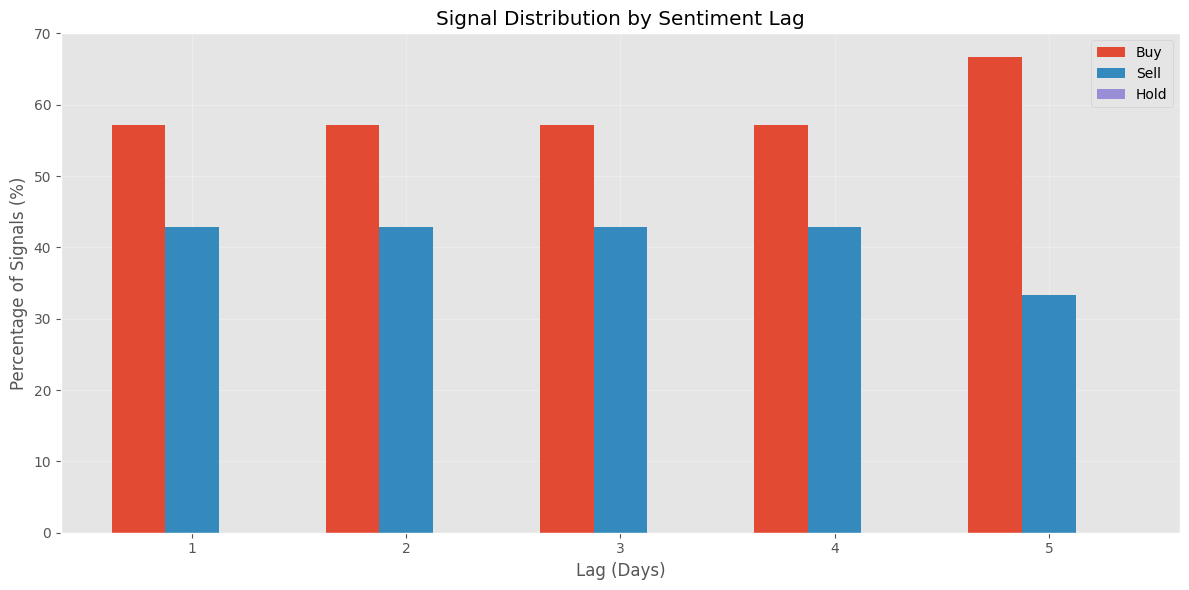

In [19]:
# Analyze how signal distribution changes with lag
signal_dist_data = []

for lag in range(1, 6):
    # Filter simulations with this lag
    lag_sims = [r for r in mc_results if r['lag'] == lag]

    if lag_sims:
        # Get average signal counts
        buy_pct = np.mean([len(s['portfolio'][s['portfolio']['signal'] == 'BUY']) / len(s['portfolio']) for s in lag_sims])
        sell_pct = np.mean([len(s['portfolio'][s['portfolio']['signal'] == 'SELL']) / len(s['portfolio']) for s in lag_sims])
        hold_pct = np.mean([len(s['portfolio'][s['portfolio']['signal'] == 'HOLD']) / len(s['portfolio']) for s in lag_sims])

        signal_dist_data.append({
            'Lag': lag,
            'Buy %': buy_pct * 100,
            'Sell %': sell_pct * 100,
            'Hold %': hold_pct * 100
        })

# Create DataFrame from the collected data
signal_dist = pd.DataFrame(signal_dist_data)

print("Signal distribution by lag:")
print(signal_dist)

# Plot signal distribution
plt.figure(figsize=(12, 6))
width = 0.25
x = np.arange(len(signal_dist))

plt.bar(x - width, signal_dist['Buy %'], width, label='Buy')
plt.bar(x, signal_dist['Sell %'], width, label='Sell')
plt.bar(x + width, signal_dist['Hold %'], width, label='Hold')

plt.title('Signal Distribution by Sentiment Lag')
plt.xlabel('Lag (Days)')
plt.ylabel('Percentage of Signals (%)')
plt.xticks(x, signal_dist['Lag'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary

In [20]:
# Create a summary of our findings
print("\n=== MONTE CARLO SIMULATION SUMMARY ===")
print(f"Number of simulations: {len(mc_results)}")
print(f"Sentiment lag range: {min(mc_df['Lag'])} to {max(mc_df['Lag'])} days")
print(f"Average strategy return: {mc_df['Return'].mean():.2%}")
print(f"Average benchmark return: {mc_df['Benchmark'].mean():.2%}")
print(f"Best strategy return: {mc_df['Return'].max():.2%} (Lag: {mc_df.loc[mc_df['Return'].idxmax(), 'Lag']})")
print(f"Worst strategy return: {mc_df['Return'].min():.2%} (Lag: {mc_df.loc[mc_df['Return'].idxmin(), 'Lag']})")
print(f"Percentage of simulations that beat benchmark: {beat_benchmark/len(mc_df):.1%}")

print("\nBest performing lag (based on average return):")
best_lag_idx = lag_comparison['Avg Return'].idxmax()
best_lag = lag_comparison.loc[best_lag_idx, 'Lag']
print(f"Lag {best_lag} days - Avg Return: {lag_comparison.loc[best_lag_idx, 'Avg Return']:.2%}")

print("\nConclusion:")
if best_lag == 0:
    print("Immediate sentiment (no lag) has the strongest predictive power for price movements.")
else:
    print(f"Sentiment with a {best_lag}-day lag has the strongest predictive power for price movements.")

print("\nTrading strategy recommendations:")
print(f"1. Use {best_lag}-day lagged sentiment for optimal trading signals")
best_lag_signal_row = signal_dist[signal_dist['Lag'] == best_lag]
if not best_lag_signal_row.empty:
    signal_dist_values = best_lag_signal_row[['Buy %', 'Sell %', 'Hold %']].values[0]
    print(f"2. Consider the signal distribution: Buy {signal_dist_values[0]:.1f}%, Sell {signal_dist_values[1]:.1f}%, Hold {signal_dist_values[2]:.1f}%")
else:
    print("2. No signal distribution data available for this lag")
print("3. Monitor drawdowns and implement stop-loss mechanisms to protect capital")


=== MONTE CARLO SIMULATION SUMMARY ===
Number of simulations: 20
Sentiment lag range: 1 to 5 days
Average strategy return: -4.13%
Average benchmark return: -6.71%
Best strategy return: -4.13% (Lag: 4)
Worst strategy return: -4.13% (Lag: 4)
Percentage of simulations that beat benchmark: 80.0%

Best performing lag (based on average return):
Lag 1 days - Avg Return: -4.13%

Conclusion:
Sentiment with a 1-day lag has the strongest predictive power for price movements.

Trading strategy recommendations:
1. Use 1-day lagged sentiment for optimal trading signals
2. Consider the signal distribution: Buy 57.1%, Sell 42.9%, Hold 0.0%
3. Monitor drawdowns and implement stop-loss mechanisms to protect capital


In [21]:
# Save results to text file
with open('nvda_sentiment_model_results.txt', 'w') as f:
    # Model performance summary
    f.write("==== Nvidia SENTIMENT TRADING MODEL RESULTS ====\n\n")

    f.write("STRATEGY PERFORMANCE:\n")
    f.write(f"Strategy Total Return: {portfolio['equity'].iloc[-1] / 10000 - 1:.2%}\n")
    f.write(f"Buy & Hold Return: {benchmark['equity'].iloc[-1] / 10000 - 1:.2%}\n")
    f.write(f"Outperformance: {portfolio['equity'].iloc[-1] / 10000 - benchmark['equity'].iloc[-1] / 10000:.2%}\n")

    f.write("\nSTRATEGY METRICS:\n")
    sharpe_ratio = portfolio['daily_return'].mean() / portfolio['daily_return'].std() * np.sqrt(252)
    max_drawdown = portfolio['drawdown'].min() if 'drawdown' in portfolio.columns else 0
    f.write(f"Sharpe Ratio: {sharpe_ratio:.2f}\n")
    f.write(f"Maximum Drawdown: {max_drawdown:.2%}\n")

    f.write("\nSIGNAL ANALYSIS:\n")
    buy_signals = len(test_df[test_df['signal'] == 'BUY'])
    sell_signals = len(test_df[test_df['signal'] == 'SELL'])
    hold_signals = len(test_df[test_df['signal'] == 'HOLD'])
    total_signals = len(test_df)

    f.write(f"Buy Signals: {buy_signals} ({buy_signals/total_signals:.1%})\n")
    f.write(f"Sell Signals: {sell_signals} ({sell_signals/total_signals:.1%})\n")
    f.write(f"Hold Signals: {hold_signals} ({hold_signals/total_signals:.1%})\n")

    f.write("\nFEATURE IMPORTANCE:\n")
    if 'feature_importances_' in dir(xgb_model):
        importances = xgb_model.feature_importances_
        indices = np.argsort(importances)[::-1]
        # Top 10 features
        for i in range(min(10, len(indices))):
            f.write(f"{feature_cols[indices[i]]}: {importances[indices[i]]:.4f}\n")

    f.write("\n==== MONTE CARLO SIMULATION RESULTS ====\n\n")
    f.write(f"Number of simulations: {len(mc_results)}\n")
    f.write(f"Sentiment lag range: {min(mc_df['Lag'])} to {max(mc_df['Lag'])} days\n")
    f.write(f"Average strategy return: {mc_df['Return'].mean():.2%}\n")
    f.write(f"Average benchmark return: {mc_df['Benchmark'].mean():.2%}\n")
    f.write(f"Best strategy return: {mc_df['Return'].max():.2%} (Lag: {mc_df.loc[mc_df['Return'].idxmax(), 'Lag']})\n")
    f.write(f"Worst strategy return: {mc_df['Return'].min():.2%} (Lag: {mc_df.loc[mc_df['Return'].idxmin(), 'Lag']})\n")
    f.write(f"Percentage of simulations that beat benchmark: {beat_benchmark/len(mc_df):.1%}\n")

    f.write("\nPERFORMANCE BY LAG:\n")
    for _, row in lag_comparison.iterrows():
        f.write(f"Lag {int(row['Lag'])} days: {row['Avg Return']:.2%} return, {row['Avg Sharpe']:.2f} Sharpe, "
                f"{row['Avg Max Drawdown']:.2%} max drawdown, {row['Beat Benchmark %']:.1f}% beat benchmark\n")

    f.write("\nSIGNAL DISTRIBUTION BY LAG:\n")
    for _, row in signal_dist.iterrows():
        f.write(f"Lag {int(row['Lag'])} days: Buy {row['Buy %']:.1f}%, Sell {row['Sell %']:.1f}%, Hold {row['Hold %']:.1f}%\n")



print("Results saved to nvda_sentiment_model_results.txt")

Results saved to nvda_sentiment_model_results.txt
